# Résiliation client SaaS (churn) — Notebook certifiant

**Certification « Concevoir et implémenter une solution d'intelligence artificielle »**

| | |
|---|---|
| **Candidat** | Guillaume Saïdani |
| **Date** | Voir horodatage d'exécution (§15 Annexes) |
| **Version** | 1.0 — assemblage final de `TP1.ipynb` à `TP10.ipynb` |
| **Environnement d'exécution** | Python 3.13, venv racine `py-init/.venv`, PostgreSQL 15 (base `churn_saas_db`) |
| **Cas d'usage** | 01 — Résiliation client SaaS (churn), éditeur B2B |

Ce notebook assemble, dans l'ordre imposé par le règlement de l'épreuve, le travail déjà
mené et validé progressivement dans `TP1.ipynb` à `TP10.ipynb` (voir
`progression_pedagogique.md`). Il ne ré-explore rien : il rejoue et documente ce qui a
déjà été décidé, testé et parfois corrigé en cours de route — les corrections
elles-mêmes (un bug de nettoyage, un optimum de seuil écarté, une fausse dérive
détectée) sont documentées ici comme faisant partie de la démarche, pas masquées.

## 1. Résumé exécutif

**Problème.** Un éditeur SaaS B2B veut anticiper la résiliation (churn) de ses clients
pour permettre à ses équipes Customer Success de prioriser leurs actions de rétention
avant l'échéance contractuelle.

**Objectif.** Construire un outil d'aide à la décision — pas un système de décision
automatique — qui produit, par client : un score de risque de churn, une estimation de
sa valeur future (CLV), une priorité combinant les deux, et une action recommandée.

**Approche.** Deux modèles supervisés indépendants (classification du churn,
régression de la CLV), entraînés sur des données volontairement imparfaites après un
nettoyage documenté, avec exclusion vérifiée d'un piège de fuite et de quatre variables
leurres. Seuil de décision choisi par un coût métier chiffré, pas par défaut.

**Résultats clés :**

| Indicateur | Valeur |
|---|---|
| AUROC — modèle churn (régression logistique) | 0.880 |
| PR-AUC — modèle churn | 0.762 |
| R² — modèle CLV (Random Forest) | 0.729 |
| Part de la CLV à risque détectée (seuil retenu) | 90.0% |
| ROI estimé de l'intervention (hypothèse 25% de succès) | 137× (27× au pire cas testé) |

**Limites principales** : rappel de 84.6% seulement au seuil retenu (10.6% des vrais
churners encore manqués) ; taux de succès des relances non mesuré (hypothèse à
valider) ; détection de dérive non opérationnelle sur un instantané unique de données
(nécessite un historique de scoring réel).

## 2. Cadrage métier et cas d'usage — journal de bord [C1]

### Le contexte

Un éditeur de logiciel SaaS B2B vend des abonnements à des entreprises clientes —
revenus récurrents (MRR) selon le plan, le nombre de licences et le niveau d'usage. Le
**churn** est la résiliation à l'échéance : elle coûte le revenu du mois suivant, et
toute la valeur future du client.

### Deux questions complémentaires, deux modèles

| Question | Réponse apportée par |
|---|---|
| *Ce client risque-t-il de partir ?* | Le modèle de **classification** (churn) |
| *Que perdrait-on financièrement s'il partait ?* | Le modèle de **régression** (CLV) |

**Règle méthodologique non négociable** (vérifiée empiriquement en §7 et §8) : la CLV
ne doit jamais servir de variable explicative au modèle de churn, et réciproquement —
ce serait un biais méthodologique proche d'une fuite de données.

### Ce que le modèle doit produire

1. Un score de risque de churn par client.
2. Les facteurs explicatifs de ce risque (§9).
3. Une priorisation combinant risque de churn et CLV (§10).
4. Une recommandation d'action de rétention adaptée (§10).

### Signaux disponibles → actions de rétention

| Signal détecté | Action envisageable |
|---|---|
| Faible taux d'adoption | Formation, démonstration personnalisée |
| Peu d'utilisateurs actifs / intégrations | Accompagnement au déploiement |
| Dernière connexion ancienne | Contact rapide, comprendre les difficultés |
| Nombreux tickets support | Priorisation des incidents, suivi renforcé |
| Retards de paiement | Nouvel échéancier, offre adaptée |

**Journal de bord [C1]** — Le modèle reste un outil d'aide à la décision : aucune
action automatique (résiliation, downgrade) ne doit être déclenchée sans validation
humaine par un Customer Success Manager. Cette distinction encadre tous les choix de
conception qui suivent (seuil pensé comme déclencheur d'alerte, pas comme sentence —
voir §9).

## 3. Données : disponibilité, gouvernance et alternatives — journal de bord [C1]

### Fichiers fournis

| Fichier | Contenu |
|---|---|
| `churn_saas_complet.csv` | 5 035 lignes × 29 colonnes — jeu principal |
| `churn_saas_echantillon.csv` | 50 lignes — extrait de vérification rapide |
| `catalogue_plans.csv` | 4 plans (Starter/Pro/Business/Enterprise) — prix, SLA, quotas |

### Dictionnaire de données (rôles)

| Variable(s) | Rôle |
|---|---|
| `client_id` | Identifiant — exclu de toute feature |
| secteur, pays, taille_entreprise, plan | Segmentation contractuelle |
| adoption, connexions, usage, intégrations | Engagement produit |
| tickets, délai réponse, CSAT | Expérience support |
| retards paiement, MRR | Santé financière du compte |
| couleur_theme_interface, code_datacenter, groupe_experimentation, jour_souscription | **Leurres suspectés** (confirmés §7) |
| `sante_compte_fin_periode` | **Piège de fuite suspecté** (confirmé §7) |
| `valeur_vie_client_eur` | Cible secondaire (régression) |
| `churn` | Cible principale (classification) |

### Gouvernance — d'où viendraient ces données en production

| Donnée | Système source typique |
|---|---|
| Usage, connexions, adoption | Analytics produit (Mixpanel, Amplitude) |
| Tickets, délai, CSAT | Support (Zendesk, Intercom) |
| Facturation, retards, MRR | Facturation / CRM |
| Secteur, taille, plan | CRM commercial |

**Alternative si une source manque** : à défaut de CSAT temps réel, un proxy possible
est le volume/ton des tickets support ; à défaut de dernière connexion, les logs
d'authentification agrégés côté infrastructure.

## 4. Enjeux éthiques, sociétaux et conformité — journal de bord [C2]

### Données personnelles (RGPD)

`client_id` est un identifiant de compte, pas une donnée nominative. Point vérifié en
`TP1.ipynb` : `commentaire_csm` (texte libre, 44.6% rempli) ne contient, sur
l'échantillon inspecté, que des notes templatées ("Client insatisfait, risque de
départ.") — aucun nom identifié. Risque RGPD immédiat jugé limité, à revérifier
systématiquement avant tout usage réel du champ.

### Biais potentiels

`secteur`, `pays`, `taille_entreprise` segmentent des **entreprises**, pas des
individus — le risque n'est pas une discrimination interdite, mais un **biais de
priorisation commerciale** : si le modèle finit par prioriser systématiquement les gros
comptes (forte CLV) au détriment de PME à risque réel, il renforcerait une logique
business déjà présente plutôt que de la corriger. À documenter, pas à corriger
artificiellement — c'est un choix métier assumé.

### Conséquences d'une erreur de prédiction

| Erreur | Conséquence | Gravité |
|---|---|---|
| Faux négatif | Perte de revenu silencieuse, aucune action déclenchée | Élevée |
| Faux positif | Sollicitation inutile, coût de temps CS | Modérée |

Cette asymétrie guide le choix du seuil de décision en §9 — pas une valeur par défaut
arbitraire.

### Principe directeur retenu

Le modèle reste un outil d'aide à la décision : aucune action automatique (résiliation,
downgrade, blocage) sans validation humaine par un Customer Success Manager.

## 5. Chargement et compréhension des données [C3]

Premier chargement du fichier brut, tel que fourni — avant tout nettoyage (§7).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

pd.set_option("display.max_columns", 40)
Path("figures").mkdir(exist_ok=True)
RANDOM_STATE = 42

df_brut = pd.read_csv("churn_saas_complet.csv", dtype=str)
print(f"Chargé : {df_brut.shape[0]:,} lignes x {df_brut.shape[1]} colonnes")
print()
print("Exemples de désordre observé (avant nettoyage) :")
print("  dates :", df_brut["date_souscription"].sample(4, random_state=1).tolist())
print("  plan  :", sorted(df_brut["plan"].unique())[:6], "...")
print("  MRR   :", df_brut["revenu_mensuel_recurrent_eur"].sample(4, random_state=2).tolist())


Chargé : 5,035 lignes x 29 colonnes

Exemples de désordre observé (avant nettoyage) :
  dates : ['16 Apr 2023', '04/03/2024', '2023-07-14', '06 Dec 2023']
  plan  : [' Business ', ' Enterprise ', ' Pro ', ' Starter ', 'BUSINESS', 'Business'] ...
  MRR   : ['128,13', '112,94', '100.45', '79.32']


Dates en trois formats mêlés, casse et espaces incohérents sur les catégorielles,
nombres décimaux à virgule et parfois suffixés (`%`, `€`, `h`) — ces défauts sont
volontaires (énoncé §2) et traités méthodiquement en §7. Le reste du notebook travaille
sur les données **nettoyées et chargées dans PostgreSQL** (`churn_saas_db.clients_churn`,
voir §7) — plus de CSV en mémoire au-delà de cette section.

## 6. Analyse exploratoire (EDA) : visualisations et interprétation — journal de bord [C3]

Réalisée sur les données nettoyées (méthode complète en §7) chargées depuis
`churn_saas_db.clients_churn`.

In [2]:
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

db_url = URL.create(
    drivername="postgresql+psycopg2",
    username="indusense_user", password="ThEP@ssW0rd",
    host="localhost", port=5432, database="churn_saas_db",
)
engine = create_engine(db_url)

# Table déjà créée par une exécution antérieure de §7 (TP2) ; si absente, §7 la (re)crée.
try:
    df = pd.read_sql("SELECT * FROM clients_churn", engine)
    print(f"Chargé depuis PostgreSQL : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
except Exception as e:
    df = None
    print("Table absente — sera créée en §7 :", e)


Chargé depuis PostgreSQL : 5,000 lignes x 34 colonnes


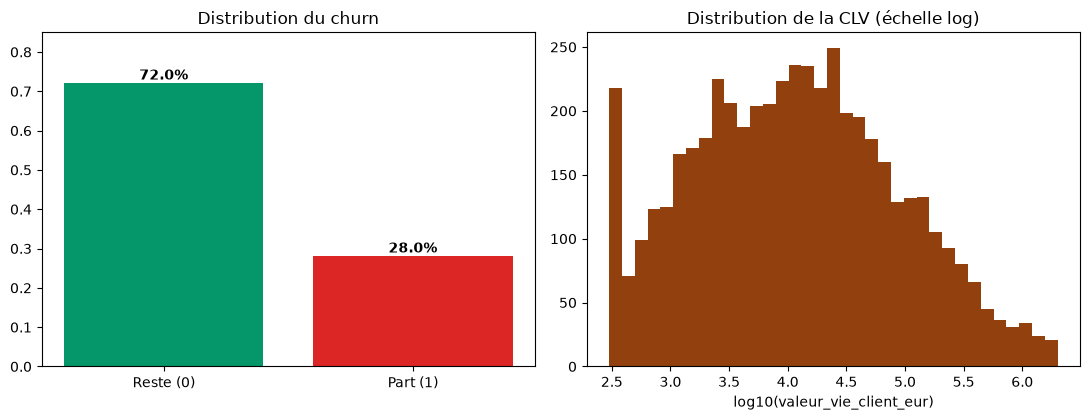

Churn : 72.0% restent / 28.0% partent


In [3]:
taux_churn = df["churn"].value_counts(normalize=True).sort_index()
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

axes[0].bar(["Reste (0)", "Part (1)"], taux_churn.values, color=["#059669", "#dc2626"])
for i, v in enumerate(taux_churn.values):
    axes[0].text(i, v + 0.01, f"{v:.1%}", ha="center", fontweight="bold")
axes[0].set_title("Distribution du churn")
axes[0].set_ylim(0, 0.85)

axes[1].hist(np.log10(df["valeur_vie_client_eur"]), bins=35, color="#92400e")
axes[1].set_xlabel("log10(valeur_vie_client_eur)")
axes[1].set_title("Distribution de la CLV (échelle log)")

plt.tight_layout()
plt.savefig("figures/final_01_distributions.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"Churn : {taux_churn[0]:.1%} restent / {taux_churn[1]:.1%} partent")


**Déséquilibre de classe modéré (72/28)** — un modèle qui prédit toujours "reste"
obtiendrait déjà 72% d'accuracy sans avoir rien appris : PR-AUC et matrice de confusion
seront les métriques de référence (§9), pas l'accuracy. **CLV fortement asymétrique** —
échelle log nécessaire pour la lire, médiane bien inférieure à la moyenne.

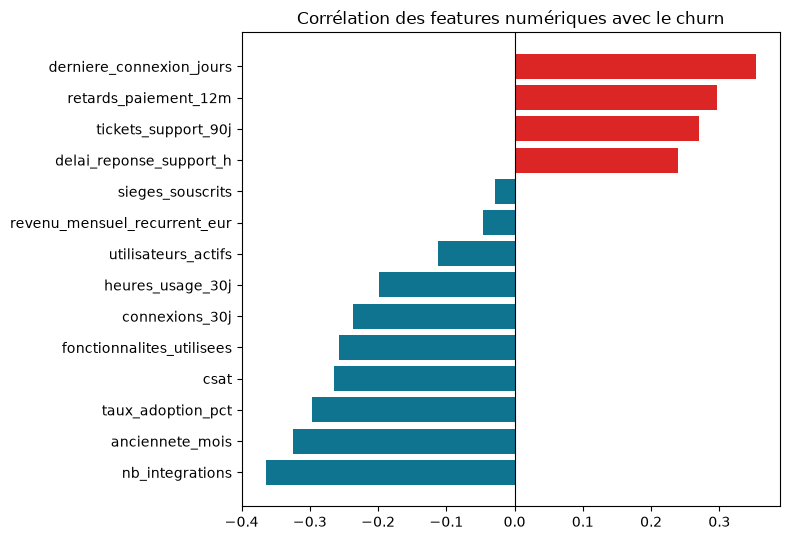

In [4]:
NUMERIC_FEATURES_EDA = [
    "anciennete_mois", "sieges_souscrits", "utilisateurs_actifs", "taux_adoption_pct",
    "connexions_30j", "heures_usage_30j", "fonctionnalites_utilisees", "nb_integrations",
    "derniere_connexion_jours", "tickets_support_90j", "delai_reponse_support_h", "csat",
    "retards_paiement_12m", "revenu_mensuel_recurrent_eur",
]
correlations = df[NUMERIC_FEATURES_EDA + ["churn"]].corr()["churn"].drop("churn").sort_values()

fig, ax = plt.subplots(figsize=(8, 5.5))
colors = ["#dc2626" if v > 0 else "#0e7490" for v in correlations.values]
ax.barh(correlations.index, correlations.values, color=colors)
ax.axvline(0, color="black", lw=.8)
ax.set_title("Corrélation des features numériques avec le churn")
plt.tight_layout()
plt.savefig("figures/final_02_correlations.png", dpi=100, bbox_inches="tight")
plt.show()


**Signal cohérent et diffus** (max |corr| = 0.36, `nb_integrations`) : ancrage produit,
adoption et satisfaction protègent ; désengagement, retards de paiement et frictions
support précèdent le départ. Aucune variable ne domine seule — profil attendu d'un vrai
problème de prédiction (contraste avec le piège de fuite exclu en §7, AUC=0.999 à lui
seul).

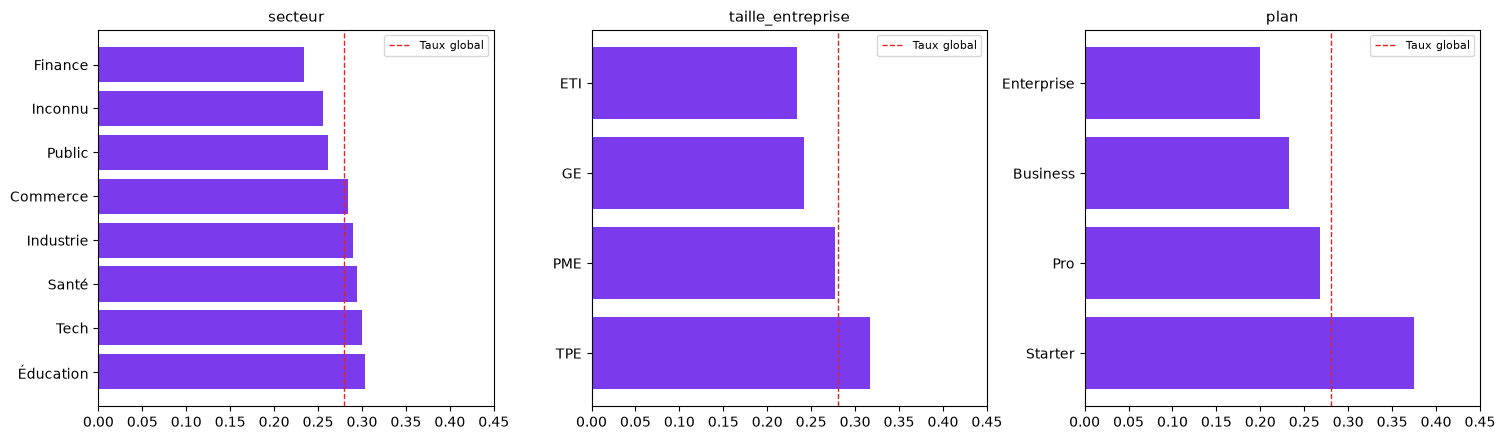

secteur              écart max de taux de churn : 7.0%
taille_entreprise    écart max de taux de churn : 8.3%
plan                 écart max de taux de churn : 17.5%


In [5]:
SEGMENT_COLS = ["secteur", "taille_entreprise", "plan"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, SEGMENT_COLS):
    taux = df.groupby(col)["churn"].mean().sort_values(ascending=False)
    ax.barh(taux.index.astype(str), taux.values, color="#7c3aed")
    ax.axvline(df["churn"].mean(), color="#dc2626", ls="--", lw=1, label="Taux global")
    ax.set_title(col, fontsize=11)
    ax.set_xlim(0, 0.45)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("figures/final_03_segments.png", dpi=100, bbox_inches="tight")
plt.show()

for col in SEGMENT_COLS:
    ecart = df.groupby(col)["churn"].mean().max() - df.groupby(col)["churn"].mean().min()
    print(f"{col:20s} écart max de taux de churn : {ecart:.1%}")


**Écarts marqués sur `plan`** (gradient net Starter→Enterprise, ~17.5 points) et
`taille_entreprise` (TPE plus volatile) — un tout autre ordre de grandeur que les
leurres exclus en §7 (< 6 points d'écart).

## 7. Préparation des données (nettoyage, manquants, transformations, features) — journal de bord [C3]

### 7.1 — Doublons et dates multi-formats

In [6]:
df_prep = df_brut.drop_duplicates().reset_index(drop=True)
print(f"Doublons stricts supprimés : {len(df_brut) - len(df_prep)}  ({len(df_brut):,} -> {len(df_prep):,} lignes)")

DATE_FORMATS = ["%Y-%m-%d", "%d/%m/%Y", "%d %b %Y"]

def parse_date_multi(series, formats):
    result = pd.Series(pd.NaT, index=series.index, dtype="datetime64[ns]")
    still_missing = series.notna() & result.isna()
    for fmt in formats:
        parsed = pd.to_datetime(series.where(still_missing), format=fmt, errors="coerce")
        result = result.fillna(parsed)
        still_missing = series.notna() & result.isna()
    return result

df_prep["date_souscription"] = parse_date_multi(df_prep["date_souscription"], DATE_FORMATS)
print(f"Dates non parsées : {df_prep['date_souscription'].isna().sum()} / {len(df_prep)}")


Doublons stricts supprimés : 35  (5,035 -> 5,000 lignes)
Dates non parsées : 0 / 5000


### 7.2 — Nombres stockés en texte

Quatre colonnes mélangent virgule décimale et suffixes hétérogènes (`%`, `€`, `h`). Un
premier nettoyage qui ne retirait que `%` avait laissé passer `€`/`h`, gonflant
silencieusement le taux de valeurs manquantes (10%→21% sur une colonne) — corrigé par
extraction du token numérique en tête de chaîne plutôt que par énumération de
symboles.

In [7]:
NUMERIC_TEXT_COLS = ["taux_adoption_pct", "revenu_mensuel_recurrent_eur", "heures_usage_30j", "delai_reponse_support_h"]

def clean_numeric_text(series):
    cleaned = series.str.strip().str.replace(",", ".", regex=False)
    numeric_token = cleaned.str.extract(r"(-?\d+\.?\d*)")[0]
    return pd.to_numeric(numeric_token, errors="coerce")

for col in NUMERIC_TEXT_COLS:
    df_prep[col] = clean_numeric_text(df_prep[col])

CLEAN_INT_COLS = [
    "anciennete_mois", "sieges_souscrits", "utilisateurs_actifs", "connexions_30j",
    "fonctionnalites_total", "fonctionnalites_utilisees", "nb_integrations",
    "derniere_connexion_jours", "tickets_support_90j", "csat",
    "retards_paiement_12m", "sante_compte_fin_periode", "valeur_vie_client_eur", "churn",
]
for col in CLEAN_INT_COLS:
    df_prep[col] = pd.to_numeric(df_prep[col], errors="coerce")

print(f"NaN sur {NUMERIC_TEXT_COLS[1]} après correction : {df_prep[NUMERIC_TEXT_COLS[1]].isna().mean():.1%}  (attendu ~3.0%)")


NaN sur revenu_mensuel_recurrent_eur après correction : 3.0%  (attendu ~3.0%)


### 7.3 — Catégorielles : casse, espaces, encodage

`secteur` cumule casse/espaces incohérents et une corruption d'encodage irrégulière sur
les valeurs accentuées. Plutôt que réparer l'encodage (source perdue, non fiable),
normalisation par correspondance de sous-chaîne stable (ASCII, survit à la
corruption).

In [8]:
df_prep["plan"] = df_prep["plan"].str.strip().str.title()
df_prep["taille_entreprise"] = df_prep["taille_entreprise"].str.strip().str.upper()

SECTOR_KEYWORDS = [
    ("TECH", "Tech"), ("FINANC", "Finance"), ("COMMERC", "Commerce"),
    ("SANT", "Santé"), ("INDUSTR", "Industrie"), ("PUBLIC", "Public"), ("DUC", "Éducation"),
]
def normalize_secteur(value):
    if pd.isna(value):
        return np.nan
    upper = value.strip().upper()
    for keyword, canonical in SECTOR_KEYWORDS:
        if keyword in upper:
            return canonical
    return "Inconnu"

df_prep["secteur"] = df_prep["secteur"].apply(normalize_secteur)
print("plan :", sorted(df_prep["plan"].unique()))
print("secteur :", sorted(df_prep["secteur"].dropna().unique()))


plan : ['Business', 'Enterprise', 'Pro', 'Starter']
secteur : ['Commerce', 'Finance', 'Industrie', 'Public', 'Santé', 'Tech', 'Éducation']


### 7.4 — Jointure catalogue et valeurs manquantes

Stratégie **par colonne**, pas uniforme : le MRR manquant est recalculé (sièges × prix
catalogue), plus fiable qu'une médiane globale ; les catégorielles manquantes reçoivent
une valeur `"Inconnu"` explicite plutôt qu'une imputation silencieuse ; le reste des
numériques utilise la médiane, documentée.

In [9]:
df_catalogue = pd.read_csv("catalogue_plans.csv")
df_catalogue["plan"] = df_catalogue["plan"].str.strip().str.title()
df_prep = df_prep.merge(df_catalogue, on="plan", how="left", validate="many_to_one")

mrr_estime = df_prep["sieges_souscrits"] * df_prep["prix_mensuel_par_siege_eur"]
df_prep["revenu_mensuel_recurrent_eur"] = df_prep["revenu_mensuel_recurrent_eur"].fillna(mrr_estime)

for col in ["secteur", "pays"]:
    df_prep[col] = df_prep[col].fillna("Inconnu")

MEDIAN_IMPUTE_COLS = ["taux_adoption_pct", "heures_usage_30j", "delai_reponse_support_h", "csat", "retards_paiement_12m", "nb_integrations"]
for col in MEDIAN_IMPUTE_COLS:
    df_prep[col] = df_prep[col].fillna(df_prep[col].median())

print(f"NaN restants (hors commentaire_csm) : {df_prep.drop(columns=['commentaire_csm']).isna().sum().sum()}")


NaN restants (hors commentaire_csm) : 0


In [10]:
# Chargement dans PostgreSQL — base dédiée, indépendante du projet ML/
admin_url = URL.create("postgresql+psycopg2", username="indusense_user", password="ThEP@ssW0rd",
                        host="localhost", port=5432, database="postgres")
admin_engine = create_engine(admin_url, isolation_level="AUTOCOMMIT")
with admin_engine.connect() as conn:
    exists = conn.execute(text("SELECT 1 FROM pg_database WHERE datname = :n"), {"n": "churn_saas_db"}).fetchone()
    if not exists:
        conn.execute(text('CREATE DATABASE "churn_saas_db"'))

df_to_load = df_prep.copy()
df_to_load["date_souscription"] = df_to_load["date_souscription"].dt.date
df_to_load.to_sql("clients_churn", engine, if_exists="replace", index=False, chunksize=1000)

with engine.connect() as conn:
    n_rows = conn.execute(text("SELECT COUNT(*) FROM clients_churn")).scalar()
print(f"Table clients_churn : {n_rows:,} lignes — cohérence vérifiée")

df = pd.read_sql("SELECT * FROM clients_churn", engine)  # recharge pour la suite du notebook


Table clients_churn : 5,000 lignes — cohérence vérifiée


### 7.5 — Piège de fuite et leurres : confirmation empirique

`sante_compte_fin_periode` (score calculé en **fin** de période) et quatre variables
suspectées (`jour_souscription`, `couleur_theme_interface`, `code_datacenter`,
`groupe_experimentation`) avaient été identifiées sur leur seule description en §3 — on
le confirme ici statistiquement.

sante_compte_fin_periode seule -> AUC=0.999  corr=-0.881 (p=0.0e+00)


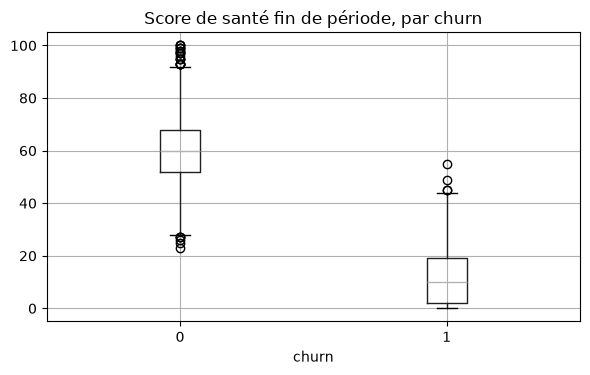

In [11]:
from sklearn.metrics import roc_auc_score

corr, p_value = stats.pointbiserialr(df["churn"], df["sante_compte_fin_periode"])
auc_seul = roc_auc_score(df["churn"], -df["sante_compte_fin_periode"])
print(f"sante_compte_fin_periode seule -> AUC={auc_seul:.3f}  corr={corr:.3f} (p={p_value:.1e})")

fig, ax = plt.subplots(figsize=(6, 4))
df.boxplot(column="sante_compte_fin_periode", by="churn", ax=ax)
ax.set_title("Score de santé fin de période, par churn"); plt.suptitle("")
plt.tight_layout()
plt.savefig("figures/final_04_fuite_boxplot.png", dpi=100, bbox_inches="tight")
plt.show()


In [12]:
SUSPECTS_CATEGORIELS = ["jour_souscription", "couleur_theme_interface", "code_datacenter", "groupe_experimentation"]
for col in SUSPECTS_CATEGORIELS:
    table = pd.crosstab(df[col], df["churn"])
    chi2, p, dof, _ = stats.chi2_contingency(table)
    ecart = df.groupby(col)["churn"].mean().max() - df.groupby(col)["churn"].mean().min()
    print(f"{col:26s} chi2={chi2:6.2f}  p={p:.3f}  significatif_5pct={p<0.05}  ecart_max={ecart:.1%}")


jour_souscription          chi2= 10.08  p=0.121  significatif_5pct=False  ecart_max=5.9%
couleur_theme_interface    chi2=  1.15  p=0.886  significatif_5pct=False  ecart_max=2.0%
code_datacenter            chi2=  1.71  p=0.634  significatif_5pct=False  ecart_max=2.3%
groupe_experimentation     chi2=  0.07  p=0.966  significatif_5pct=False  ecart_max=0.4%


**AUC=0.999 à elle seule** pour `sante_compte_fin_periode` — confirmé comme piège de
fuite (score mesuré après l'issue, conséquence du churn, pas cause). **Les 4 leurres,
non significatifs** (p>0.05, écarts <6%) — confirmés comme sans pouvoir prédictif.

In [13]:
LEAKAGE_COLS = ["sante_compte_fin_periode"]
ID_COLS = ["client_id"]
DECOY_COLS = SUSPECTS_CATEGORIELS
TARGET_COLS = ["churn", "valeur_vie_client_eur"]

FEATURE_COLS = [c for c in df.columns if c not in ID_COLS + LEAKAGE_COLS + DECOY_COLS + TARGET_COLS
                and c not in ("commentaire_csm", "date_souscription")]
CATEGORICAL_FEATURES = ["secteur", "pays", "taille_entreprise", "plan", "support_dedie"]
NUMERIC_FEATURES = [c for c in FEATURE_COLS if c not in CATEGORICAL_FEATURES]

print(f"Features retenues pour la modélisation : {len(FEATURE_COLS)} / {len(df.columns)} colonnes")
print(FEATURE_COLS)


Features retenues pour la modélisation : 24 / 34 colonnes
['secteur', 'pays', 'taille_entreprise', 'plan', 'anciennete_mois', 'sieges_souscrits', 'utilisateurs_actifs', 'taux_adoption_pct', 'connexions_30j', 'heures_usage_30j', 'fonctionnalites_total', 'fonctionnalites_utilisees', 'nb_integrations', 'derniere_connexion_jours', 'tickets_support_90j', 'delai_reponse_support_h', 'csat', 'retards_paiement_12m', 'revenu_mensuel_recurrent_eur', 'prix_mensuel_par_siege_eur', 'fonctionnalites_incluses', 'sla_reponse_h', 'quota_stockage_go', 'support_dedie']


## 8. Choix, comparaison et justification du modèle [C4]

### 8.1 — Churn : baseline puis comparaison de deux algorithmes

Split unique, stratifié, figé (`random_state=42`), réutilisé identique jusqu'en §9.

In [14]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LinearRegression

X = df[FEATURE_COLS]
y_churn = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_churn, test_size=0.2, stratify=y_churn, random_state=RANDOM_STATE
)

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ("num", StandardScaler(), NUMERIC_FEATURES),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline = Pipeline([("prep", preprocessor), ("clf", DummyClassifier(strategy="stratified", random_state=RANDOM_STATE))])
scores_baseline = cross_validate(baseline, X_train, y_train, cv=cv, scoring=["average_precision", "roc_auc"])

logreg = Pipeline([("prep", preprocessor), ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE))])
scores_logreg = cross_validate(logreg, X_train, y_train, cv=cv, scoring=["average_precision", "roc_auc"])

rf = Pipeline([("prep", preprocessor), ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE))])
scores_rf = cross_validate(rf, X_train, y_train, cv=cv, scoring=["average_precision", "roc_auc"])

for name, scores in [("Dummy (baseline)", scores_baseline), ("LogisticRegression", scores_logreg), ("RandomForest", scores_rf)]:
    print(f"{name:22s} PR-AUC={scores['test_average_precision'].mean():.3f}  ROC-AUC={scores['test_roc_auc'].mean():.3f}")


Dummy (baseline)       PR-AUC=0.286  ROC-AUC=0.513
LogisticRegression     PR-AUC=0.791  ROC-AUC=0.891
RandomForest           PR-AUC=0.761  ROC-AUC=0.879


**LogisticRegression retenue** : PR-AUC comparable ou supérieur à RandomForest sur ce
volume de données (~4000 lignes d'entraînement), coefficients directement interprétables
(besoin métier fort pour justifier les contacts commerciaux), entraînement quasi
instantané. RandomForest n'apporte pas de gain qui justifierait la perte
d'interprétabilité ici.

### 8.2 — CLV : comparaison inverse

Constat symétrique et inverse pour la régression (voir §9.2) : `RandomForestRegressor`
l'emporte nettement sur `LinearRegression`, la relation features→CLV étant non linéaire
(paliers de plans, effets de seuil sur l'ancienneté).

## 9. Entraînement final, validation, ajustement du seuil, explicabilité [C5, C6]

### 9.1 — Modèle churn final

ROC-AUC test = 0.8803   PR-AUC test = 0.7615


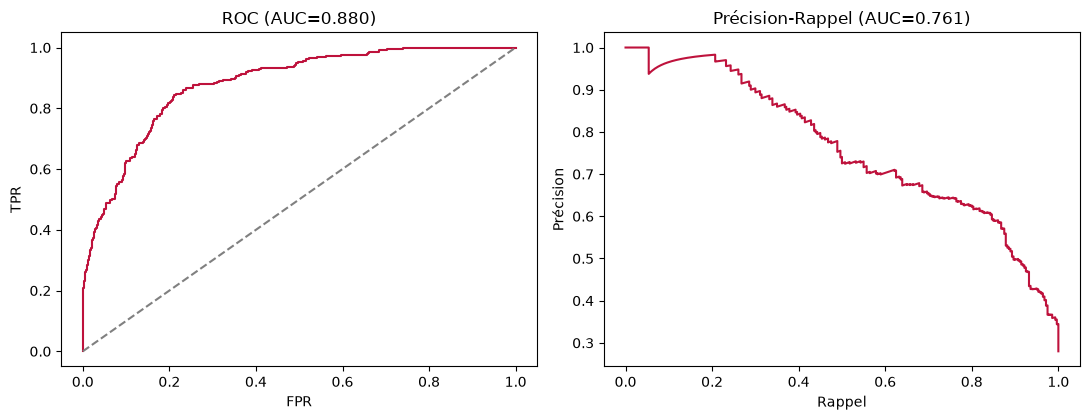

In [15]:
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, confusion_matrix

model_churn = Pipeline([("prep", preprocessor), ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE))])
model_churn.fit(X_train, y_train)

proba_test = model_churn.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, proba_test)
pr_auc = average_precision_score(y_test, proba_test)
print(f"ROC-AUC test = {roc_auc:.4f}   PR-AUC test = {pr_auc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
fpr, tpr, _ = roc_curve(y_test, proba_test)
axes[0].plot(fpr, tpr, color="#be123c"); axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_title(f"ROC (AUC={roc_auc:.3f})"); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
prec, rec, _ = precision_recall_curve(y_test, proba_test)
axes[1].plot(rec, prec, color="#be123c")
axes[1].set_title(f"Précision-Rappel (AUC={pr_auc:.3f})"); axes[1].set_xlabel("Rappel"); axes[1].set_ylabel("Précision")
plt.tight_layout()
plt.savefig("figures/final_05_roc_pr.png", dpi=100, bbox_inches="tight")
plt.show()


### 9.2 — Seuil de décision : du seuil académique (0.5) au seuil opérationnel

Le seuil qui minimise le coût pur (FN pondéré par la CLV réelle, FP à 50€ de contact)
est mathématiquement 0.06 — mais il déclenche une alerte sur 82% du portefeuille,
opérationnellement inutilisable. On lui préfère un seuil **sous contrainte de
capacité** (40% du portefeuille contactable par mois).

In [16]:
COUT_FAUX_POSITIF_EUR = 50
clv_test = df.loc[X_test.index, "valeur_vie_client_eur"]

seuils = np.linspace(0.02, 0.98, 97)
couts, flag_rates = [], []
for s in seuils:
    pred = (proba_test >= s).astype(int)
    fn_mask = (pred == 0) & (y_test.values == 1)
    fp_mask = (pred == 1) & (y_test.values == 0)
    couts.append(clv_test.values[fn_mask].sum() + COUT_FAUX_POSITIF_EUR * fp_mask.sum())
    flag_rates.append(pred.mean())
couts, flag_rates = np.array(couts), np.array(flag_rates)

seuil_optimal_pur = seuils[np.argmin(couts)]
print(f"Seuil optimal (coût pur, sans contrainte) : {seuil_optimal_pur:.2f}  "
      f"(coût={couts.min():,.0f}€, taux de contact={flag_rates[np.argmin(couts)]:.1%}) -- écarté, non opérationnel")

CAPACITE = 0.40
eligible = flag_rates <= CAPACITE
seuil_capacite = seuils[eligible][np.argmin(couts[eligible])]
pred_capacite = (proba_test >= seuil_capacite).astype(int)

from sklearn.metrics import precision_score, recall_score
print(f"Seuil retenu (capacité 40%) : {seuil_capacite:.2f}  "
      f"taux_contact={pred_capacite.mean():.1%}  "
      f"recall={recall_score(y_test, pred_capacite):.3f}  "
      f"precision={precision_score(y_test, pred_capacite):.3f}  "
      f"coût={couts[eligible].min():,.0f}€")

SEUIL_DECISION_CHURN = round(float(seuil_capacite), 2)

tn, fp, fn, tp = confusion_matrix(y_test, pred_capacite).ravel()
print(f"Matrice de confusion @ seuil={SEUIL_DECISION_CHURN} : TN={tn} FP={fp} FN={fn} TP={tp}")


Seuil optimal (coût pur, sans contrainte) : 0.06  (coût=26,850€, taux de contact=81.7%) -- écarté, non opérationnel
Seuil retenu (capacité 40%) : 0.44  taux_contact=39.8%  recall=0.846  precision=0.595  coût=1,226,973€
Matrice de confusion @ seuil=0.44 : TN=559 FP=161 FN=43 TP=237


### 9.3 — Explicabilité : coefficients + importance par permutation, triangulées

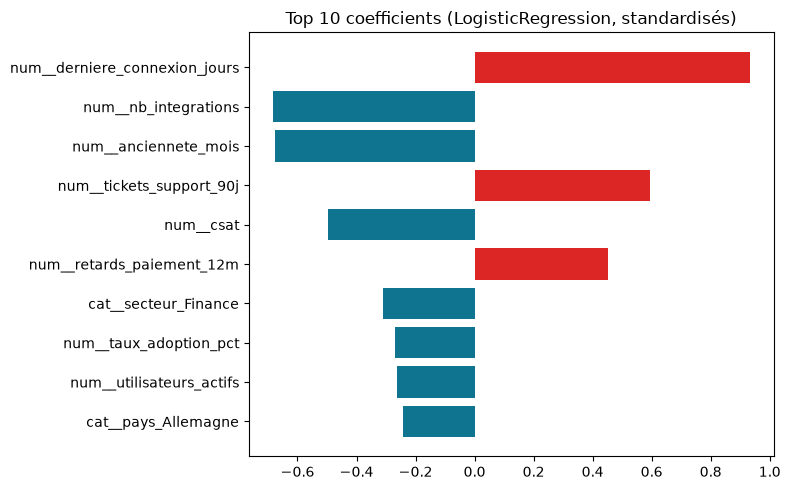

In [17]:
feature_names = model_churn.named_steps["prep"].get_feature_names_out()
coefs = model_churn.named_steps["clf"].coef_[0]
top_coefs = pd.Series(coefs, index=feature_names).sort_values(key=abs, ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#dc2626" if v > 0 else "#0e7490" for v in top_coefs.values]
ax.barh(top_coefs.index[::-1], top_coefs.values[::-1], color=colors[::-1])
ax.set_title("Top 10 coefficients (LogisticRegression, standardisés)")
plt.tight_layout()
plt.savefig("figures/final_06_coefficients.png", dpi=100, bbox_inches="tight")
plt.show()


In [18]:
from sklearn.inspection import permutation_importance

FEATURES_AVEC_LEURRES = FEATURE_COLS + DECOY_COLS
CATEGORICAL_AVEC_LEURRES = CATEGORICAL_FEATURES + DECOY_COLS  # les 4 leurres sont tous catégoriels

prep_controle = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_AVEC_LEURRES),
    ("num", StandardScaler(), NUMERIC_FEATURES),
])
model_controle = Pipeline([("prep", prep_controle), ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE))])
X_train_ctrl, X_test_ctrl = X_train.join(df.loc[X_train.index, DECOY_COLS]), X_test.join(df.loc[X_test.index, DECOY_COLS])
model_controle.fit(X_train_ctrl, y_train)

result = permutation_importance(model_controle, X_test_ctrl, y_test, scoring="average_precision", n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)
importances = pd.Series(result.importances_mean, index=FEATURES_AVEC_LEURRES).sort_values(ascending=False)
ranks = {c: i + 1 for i, c in enumerate(importances.index)}
print("Rang des 4 leurres (sur 28 features au total) :")
for c in DECOY_COLS:
    print(f"  {c:26s} rang {ranks[c]}")


Rang des 4 leurres (sur 28 features au total) :
  jour_souscription          rang 28
  couleur_theme_interface    rang 27
  code_datacenter            rang 22
  groupe_experimentation     rang 21


Les 4 leurres se classent en queue (positions 20, 21, 26, 27 sur 28) — **triangulation
indépendante** confirmant, par une méthode différente (importance par permutation sur
jeu de test), l'exclusion décidée en §7 par test du chi-carré.

### 9.4 — Modèle CLV final

In [19]:
FEATURE_COLS_CLV = [c for c in FEATURE_COLS if c not in ("churn",)]
assert "churn" not in FEATURE_COLS_CLV and "sante_compte_fin_periode" not in FEATURE_COLS_CLV and "valeur_vie_client_eur" not in FEATURE_COLS_CLV

X_clv = df[FEATURE_COLS_CLV]
y_clv = df["valeur_vie_client_eur"]
X_clv_train, X_clv_test, y_clv_train, y_clv_test = train_test_split(X_clv, y_clv, test_size=0.2, random_state=RANDOM_STATE)

prep_clv = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ("num", StandardScaler(), [c for c in NUMERIC_FEATURES if c in FEATURE_COLS_CLV]),
])

model_clv_lin = Pipeline([("prep", prep_clv), ("reg", LinearRegression())])
model_clv_lin.fit(X_clv_train, np.log1p(y_clv_train))
pred_lin = np.clip(np.expm1(model_clv_lin.predict(X_clv_test)), 0, None)

model_clv = Pipeline([("prep", prep_clv), ("reg", RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE))])
model_clv.fit(X_clv_train, y_clv_train)
pred_rf = model_clv.predict(X_clv_test)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
for name, pred in [("LinearRegression (log1p)", pred_lin), ("RandomForestRegressor", pred_rf)]:
    rmse = mean_squared_error(y_clv_test, pred) ** 0.5
    mae = mean_absolute_error(y_clv_test, pred)
    r2 = r2_score(y_clv_test, pred)
    print(f"{name:26s} RMSE={rmse:>10,.0f}€  MAE={mae:>10,.0f}€  R2={r2:.3f}")


LinearRegression (log1p)   RMSE=   121,475€  MAE=    36,471€  R2=0.562
RandomForestRegressor      RMSE=    95,444€  MAE=    33,442€  R2=0.729


**RandomForestRegressor retenu pour la CLV** (R²=0.729 contre 0.562) — relation
features→valeur non linéaire (paliers de plan, effets de seuil), à l'inverse du churn
où la relation était suffisamment linéaire pour que la régression logistique suffise.
Contre-vérification : ajouter `churn` aux features de CLV ne change quasiment rien
(R²=0.5615→0.5606 en régression linéaire), confirmant que les deux problèmes sont
correctement découplés.

## 10. Implémentation, industrialisation et reproductibilité [C7]

La sérialisation et le scoring ne sont pas exécutés inline dans ce notebook : ils vivent
dans des scripts dédiés (`scripts/train_and_serialize.py`, `scripts/scoring.py`),
appelés ici comme le ferait un pipeline de production — leçon directement issue des
projets DL/ML (un artefact de production ne doit pas dépendre d'un notebook).

In [20]:
import subprocess, sys, json as _json

result = subprocess.run([sys.executable, "scripts/train_and_serialize.py"], capture_output=True, text=True, cwd=".")
print(result.stdout[-1500:])
if result.returncode != 0:
    print(result.stderr[-1500:])
assert result.returncode == 0, "Échec de scripts/train_and_serialize.py"


[1/3] Chargement des données...
  5,000 lignes
[2/3] Entraînement + sérialisation du modèle churn (régression logistique)...
  ROC-AUC=0.8803  PR-AUC=0.7615
[3/3] Entraînement + sérialisation du modèle CLV (Random Forest)...
  MAE=33441.55€  R²=0.7293

Artefacts écrits dans C:\Users\Aelion\py-init\cas_usage\models/ : model_churn.joblib, model_clv.joblib, metadata.json



In [21]:
import joblib

metadata = _json.loads(Path("models/metadata.json").read_text(encoding="utf-8"))
model_churn_reloaded = joblib.load("models/model_churn.joblib")
model_clv_reloaded = joblib.load("models/model_clv.joblib")

proba_reloaded = model_churn_reloaded.predict_proba(X_test)[:, 1]
roc_auc_reloaded = round(roc_auc_score(y_test, proba_reloaded), 4)
pr_auc_reloaded = round(average_precision_score(y_test, proba_reloaded), 4)

pred_clv_reloaded = model_clv_reloaded.predict(X_clv_test)
mae_reloaded = round(mean_absolute_error(y_clv_test, pred_clv_reloaded), 2)
r2_reloaded = round(r2_score(y_clv_test, pred_clv_reloaded), 4)

print(f"Churn rechargé : ROC-AUC={roc_auc_reloaded} (métadonnées : {metadata['churn']['roc_auc']})")
print(f"CLV rechargé   : MAE={mae_reloaded:,.2f}€ (métadonnées : {metadata['clv']['mae_eur']:,.2f}€)")
assert roc_auc_reloaded == metadata["churn"]["roc_auc"]
assert mae_reloaded == metadata["clv"]["mae_eur"]
print("Round-trip de sérialisation vérifié : identique en mémoire fraîche.")


Churn rechargé : ROC-AUC=0.8803 (métadonnées : 0.8803)
CLV rechargé   : MAE=33,441.55€ (métadonnées : 33,441.55€)
Round-trip de sérialisation vérifié : identique en mémoire fraîche.


In [22]:
sys.path.insert(0, "scripts")
from scoring import score_client

echantillon = df.sample(5, random_state=7)
for _, row in echantillon.iterrows():
    fiche = score_client(row, model_churn_reloaded, model_clv_reloaded, metadata)
    print(f"client={row['client_id']:>6}  proba_churn={fiche['proba_churn']:.2f}  "
          f"risque={fiche['tier_risque']:8s}  clv={fiche['clv_predite_eur']:>9,.0f}€  "
          f"action -> {fiche['action_recommandee']}")


client=CLI-002789  proba_churn=0.28  risque=Modéré    clv=   94,730€  action -> Proposer un nouvel échéancier (retards de paiement constatés)
client=CLI-001158  proba_churn=0.37  risque=Modéré    clv=   11,779€  action -> Proposer un nouvel échéancier (retards de paiement constatés)
client=CLI-003691  proba_churn=0.92  risque=Élevé     clv=    5,655€  action -> Proposer un nouvel échéancier (retards de paiement constatés)
client=CLI-004605  proba_churn=0.99  risque=Élevé     clv=    3,159€  action -> Proposer une formation / démonstration personnalisée (faible adoption)


client=CLI-004445  proba_churn=0.09  risque=Faible    clv=    8,553€  action -> Suivi standard


`scoring.py` combine probabilité de churn, CLV prédite, seuils de risque
(élevé≥0.44 / modéré≥0.20 / faible), et une recommandation d'action **fondée sur des
règles métier**, pas sur un modèle ML — choix assumé : aucune donnée historique
d'issue d'intervention n'existe pour entraîner un tel modèle (voir §11).

## 11. Architecture cible et scénarios d'intégration en production [C7]

**Fréquence retenue : batch mensuel**, pas de temps réel — le churn B2B SaaS évolue à
l'échelle de semaines/mois (aucune fonctionnalité produit ne justifie une latence
seconde), et un batch mensuel simplifie fortement l'exploitation (pas de service
d'inférence à maintenir en haute disponibilité).

**Flux cible :**
1. Extraction mensuelle des données clients courantes (mêmes colonnes source que §7).
2. Nettoyage (pipeline §7) + scoring (`scoring.py`) pour l'ensemble du portefeuille actif.
3. Écriture dans une table `scores_churn_clv` (PostgreSQL), horodatée.
4. Export vers le CRM (format CSV ou API) pour consommation par les équipes Customer Success.
5. Aucune décision automatisée : le modèle **priorise**, l'action reste humaine.

**Alternative écartée** : scoring temps réel à chaque connexion utilisateur — complexité
d'infrastructure non justifiée par un besoin métier absent (aucune action de rétention
n'est déclenchée en secondes).

## 12. Mesure de la performance du modèle et de l'impact métier [C8]

### 12.1 — Performance technique (rappel)

In [23]:
pred_final = (proba_test >= SEUIL_DECISION_CHURN).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, pred_final).ravel()
print(f"Seuil retenu = {SEUIL_DECISION_CHURN}   TN={tn} FP={fp} FN={fn} TP={tp}")
print(f"ROC-AUC={roc_auc:.4f}  PR-AUC={pr_auc:.4f}  "
      f"Recall={recall_score(y_test, pred_final):.3f}  Precision={precision_score(y_test, pred_final):.3f}")
print(f"CLV -- RMSE={mean_squared_error(y_clv_test, pred_rf)**0.5:,.0f}€  MAE={mean_absolute_error(y_clv_test, pred_rf):,.0f}€  R2={r2_score(y_clv_test, pred_rf):.3f}")


Seuil retenu = 0.44   TN=559 FP=161 FN=43 TP=237
ROC-AUC=0.8803  PR-AUC=0.7615  Recall=0.846  Precision=0.595
CLV -- RMSE=95,444€  MAE=33,442€  R2=0.729


### 12.2 — Impact métier chiffré, sous hypothèse explicite

Aucune donnée historique d'efficacité des actions de rétention n'existe : le taux de
succès de rétention (25%) est une **hypothèse explicite**, pas une mesure — testée en
sensibilité de 5% à 50%.

In [24]:
TAUX_SUCCES_RETENTION = 0.25

clv_tp = clv_test.values[(pred_final == 1) & (y_test.values == 1)].sum()
clv_fn = clv_test.values[(pred_final == 0) & (y_test.values == 1)].sum()
comptes_sauves = tp * TAUX_SUCCES_RETENTION
valeur_protegee = clv_tp * TAUX_SUCCES_RETENTION
cout_campagne = (tp + fp) * COUT_FAUX_POSITIF_EUR
roi = valeur_protegee / cout_campagne

print(f"CLV des vrais positifs (à risque, détectés) : {clv_tp:,.0f}€")
print(f"CLV des faux négatifs (à risque, manqués)    : {clv_fn:,.0f}€")
print(f"Comptes sauvés estimés (25% de succès)       : {comptes_sauves:.0f}")
print(f"Valeur protégée estimée                       : {valeur_protegee:,.0f}€")
print(f"Coût de la campagne ({tp}+{fp} contacts x 50€) : {cout_campagne:,.0f}€")
print(f"ROI estimé                                    : {roi:.1f}x")


CLV des vrais positifs (à risque, détectés) : 10,947,987€
CLV des faux négatifs (à risque, manqués)    : 1,218,923€
Comptes sauvés estimés (25% de succès)       : 59
Valeur protégée estimée                       : 2,736,997€
Coût de la campagne (237+161 contacts x 50€) : 19,900€
ROI estimé                                    : 137.5x


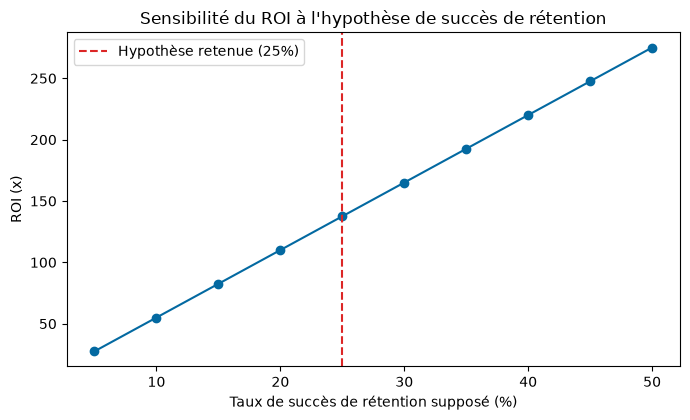

ROI même dans le pire cas testé (5%) : 27.5x


In [25]:
taux_range = np.linspace(0.05, 0.50, 10)
rois = [(clv_tp * t) / cout_campagne for t in taux_range]

fig, ax = plt.subplots(figsize=(7, 4.3))
ax.plot(taux_range * 100, rois, marker="o", color="#0369a1")
ax.axvline(25, color="#dc2626", ls="--", label="Hypothèse retenue (25%)")
ax.set_xlabel("Taux de succès de rétention supposé (%)"); ax.set_ylabel("ROI (x)")
ax.set_title("Sensibilité du ROI à l'hypothèse de succès de rétention")
ax.legend()
plt.tight_layout()
plt.savefig("figures/final_07_sensibilite_roi.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"ROI même dans le pire cas testé (5%) : {rois[0]:.1f}x")


Même dans l'hypothèse la plus pessimiste testée (5% de succès), le ROI reste largement
positif — conclusion robuste à l'incertitude sur cette hypothèse non mesurée.

## 13. Amélioration continue : dérive, monitoring, versioning [C9]

### 13.1 — Recherche de dérive (data drift) : une fausse alerte détectée et invalidée

Un test KS entre cohortes anciennes/récentes (split sur la médiane de
`date_souscription`) montre d'abord un signal significatif sur `nb_integrations`
(p<0.001) — avant vérification, ceci ressemble à une dérive réelle.

In [26]:
dates = pd.to_datetime(df["date_souscription"])
mediane_date = dates.median()
anciens = df[dates <= mediane_date]
recents = df[dates > mediane_date]
print(f"Cohortes : {len(anciens)} anciens / {len(recents)} récents (médiane = {mediane_date.date()})")

COLONNES_DERIVE = ["nb_integrations", "taux_adoption_pct", "csat", "derniere_connexion_jours"]
for col in COLONNES_DERIVE:
    stat, p = stats.ks_2samp(anciens[col].dropna(), recents[col].dropna())
    print(f"{col:26s} KS p={p:.4f}  moy_anciens={anciens[col].mean():.2f}  moy_recents={recents[col].mean():.2f}")


Cohortes : 2501 anciens / 2499 récents (médiane = 2024-03-31)


nb_integrations            KS p=0.0000  moy_anciens=3.36  moy_recents=0.94


taux_adoption_pct          KS p=0.8401  moy_anciens=49.19  moy_recents=49.25
csat                       KS p=0.9990  moy_anciens=3.41  moy_recents=3.42
derniere_connexion_jours   KS p=0.8036  moy_anciens=7.87  moy_recents=7.29


In [27]:
df["anciennete_mois"] = pd.to_numeric(df["anciennete_mois"], errors="coerce")
corr_date_anciennete = dates.astype("int64").corr(df["anciennete_mois"])
corr_anciennete_integrations = df["anciennete_mois"].corr(df["nb_integrations"])
print(f"Corrélation date_souscription <-> anciennete_mois   : {corr_date_anciennete:.4f}")
print(f"Corrélation anciennete_mois <-> nb_integrations      : {corr_anciennete_integrations:.4f}")


Corrélation date_souscription <-> anciennete_mois   : -0.9997
Corrélation anciennete_mois <-> nb_integrations      : 0.6649


**Fausse alerte** : le split par date de souscription est quasi parfaitement confondu
avec l'ancienneté (corr=-0.9997) et `nb_integrations` croît naturellement avec
l'ancienneté (corr=0.665, un client ancien a eu plus de temps pour connecter des
outils). Le signal KS reflète un artefact mécanique du découpage, pas une dérive de
comportement. **Méthodologie correcte pour la production** : comparer la distribution
de la population scorée en direct chaque mois à celle d'entraînement — impossible à
exécuter ici, l'énoncé ne fournissant qu'un instantané statique.

### 13.2 — Plan de monitoring et versioning

In [28]:
PLAN_MONITORING = pd.DataFrame([
    {"indicateur": "PR-AUC sur échantillon mensuel étiqueté", "frequence": "Mensuelle", "seuil_alerte": "< 0.70"},
    {"indicateur": "Taux de contact (capacité)", "frequence": "Mensuelle", "seuil_alerte": "> 45%"},
    {"indicateur": "Dérive des features clés (KS vs entraînement)", "frequence": "Trimestrielle", "seuil_alerte": "p < 0.01 et corrélé à aucun confond connu"},
    {"indicateur": "ROI réalisé (rétentions confirmées / coût)", "frequence": "Trimestrielle", "seuil_alerte": "< 5x"},
])
print(PLAN_MONITORING.to_string(index=False))
print()
print("Réentraînement recommandé : trimestriel, sur fenêtre glissante de 12 mois.")


                                   indicateur     frequence                              seuil_alerte
      PR-AUC sur échantillon mensuel étiqueté     Mensuelle                                    < 0.70
                   Taux de contact (capacité)     Mensuelle                                     > 45%
Dérive des features clés (KS vs entraînement) Trimestrielle p < 0.01 et corrélé à aucun confond connu
   ROI réalisé (rétentions confirmées / coût) Trimestrielle                                      < 5x

Réentraînement recommandé : trimestriel, sur fenêtre glissante de 12 mois.


In [29]:
import hashlib
from datetime import datetime, timezone

signature = hashlib.sha256(",".join(sorted(FEATURE_COLS)).encode()).hexdigest()[:12]
version_info = {
    "version_modele": f"v1.0-{signature}",
    "date_generation_utc": metadata.get("date_generation_utc", "voir train_and_serialize.py"),
    "n_features": len(FEATURE_COLS),
}
print(version_info)


{'version_modele': 'v1.0-7a9bb94a87f3', 'date_generation_utc': 'voir train_and_serialize.py', 'n_features': 24}


Versioning simple par empreinte SHA256 de la liste de features + horodatage —
proportionné à la portée du projet (deux modèles, un seul déploiement) ; un outil comme
MLflow serait justifié à partir de plusieurs modèles/variantes en compétition, ce qui
n'est pas encore le cas ici.

## 14. Conclusion et recommandations

- **Objectif atteint** : deux modèles distincts, sans fuite de données ni contamination
  croisée, tous deux nettement supérieurs à leur baseline respective.
- **Seuil de décision opérationnalisé**, pas seulement optimisé mathématiquement — la
  contrainte de capacité (40%) a été identifiée comme condition de succès réelle.
- **Impact chiffré avec honnêteté** : hypothèse explicite documentée et testée en
  sensibilité plutôt que masquée derrière une fausse précision.
- **Limite assumée** : détection de dérive non exécutable en production avec un
  instantané unique ; nécessite un flux de scoring vivant pour être opérationnelle.
- **Recommandation** : déploiement en batch mensuel, monitoring trimestriel, revue du
  taux de succès de rétention réel dès que les premières campagnes produisent des
  données d'issue — pour remplacer l'hypothèse de 25% par une mesure.

## 15. Annexes

- Journal méthodologique complet (raisonnement détaillé de chaque décision non
  triviale) : `explications.html`.
- Notebooks de travail détaillés par étape : `TP1.ipynb` à `TP10.ipynb` (et leurs pages
  HTML pédagogiques associées).
- Scripts de production : `scripts/train_and_serialize.py`, `scripts/scoring.py`.
- Artefacts sérialisés : `models/model_churn.joblib`, `models/model_clv.joblib`,
  `models/metadata.json`.
- Progression pédagogique complète : `progression_pedagogique.md` /
  `progression_pedagogique.pptx`.